In [ ]:
# # Arabic Handwritten Digit Recognition using CNN and TensorFlow

# This project implements an Arabic handwritten digit recognition system using Convolutional Neural Networks (CNN) and the MAHDBase dataset.

# ## Features
# - Image preprocessing
# - CNN-based digit classification
# - Confusion Matrix visualization
# - Classification Report
# - Multi-digit prediction

# ## Dataset
# MAHDBase Arabic Handwritten Digits Dataset

# ## Technologies
# - Python
# - TensorFlow
# - OpenCV
# - NumPy
# - Matplotlib
# - Scikit-Learn

In [1]:
!apt-get install unrar -y

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.utils import to_categorical

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 53 not upgraded.


Upload Dataset

In [3]:
from google.colab import files

print("Upload MAHDBase_TrainingSet.rar")
uploaded_train = files.upload()

print("Upload MAHDBase_TestingSet.rar")
uploaded_test = files.upload()

Upload MAHDBase_TrainingSet.rar


Saving MAHDBase_TrainingSet.rar to MAHDBase_TrainingSet.rar
Upload MAHDBase_TestingSet.rar


Saving MAHDBase_TestingSet.rar to MAHDBase_TestingSet.rar


Extract Dataset

In [4]:
!unrar x MAHDBase_TrainingSet.rar
!unrar x MAHDBase_TestingSet.rar

Streaming output truncated to the last 5000 lines.
Extracting  MAHDBase_TestingSet/Part02/writer651_pass01_digit9.bmp        10%  OK 
Extracting  MAHDBase_TestingSet/Part02/writer651_pass02_digit0.bmp        10%  OK 
Extracting  MAHDBase_TestingSet/Part02/writer651_pass02_digit1.bmp        10%  OK 
Extracting  MAHDBase_TestingSet/Part02/writer651_pass02_digit2.bmp        10%  OK 
Extracting  MAHDBase_TestingSet/Part02/writer651_pass02_digit3.bmp        10%  OK 
Extracting  MAHDBase_TestingSet/Part02/writer651_pass02_digit4.bmp        10%  OK 
Extracting  MAHDBase_TestingSet/Part02/writer651_pass02_digit5.bmp        10%  OK 
Extracting  MAHDBase_TestingSet/Part02/writer651_pass02_digit6.bmp        10%  OK 
Extracting  MAHDBase_TestingSet/Part02/writer651_pass02_digit7.bmp        10%  OK 
Extracting  MAHDBase_TestingSet/Part02/writer651_pass02_digit8.bmp        10%  OK 
Extracting  MAHDBase_TestingS

Load Dataset

In [5]:
def get_label_from_filename(filename):
    name = os.path.splitext(filename)[0]
    for char in reversed(name):
        if char.isdigit():
            return int(char)
    return None


def load_dataset(dataset_path):
    images = []
    labels = []

    for part in os.listdir(dataset_path):
        part_path = os.path.join(dataset_path, part)

        if not os.path.isdir(part_path):
            continue

        for image_name in os.listdir(part_path):
            if not image_name.lower().endswith((".bmp", ".png", ".jpg", ".jpeg")):
                continue

            image_path = os.path.join(part_path, image_name)
            label = get_label_from_filename(image_name)

            if label is None:
                continue

            image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

            if image is None:
                continue

            image = cv2.resize(image, (28, 28))
            image = image / 255.0

            images.append(image)
            labels.append(label)

    images = np.array(images).reshape(-1, 28, 28, 1)
    labels = np.array(labels)

    return images, labels


train_path = "/content/MAHDBase_TrainingSet"
test_path = "/content/MAHDBase_TestingSet"

X_train, y_train = load_dataset(train_path)
X_test, y_test = load_dataset(test_path)

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Training images:", X_train.shape)
print("Testing images:", X_test.shape)

Training images: (60000, 28, 28, 1)
Testing images: (10000, 28, 28, 1)


Show Samples

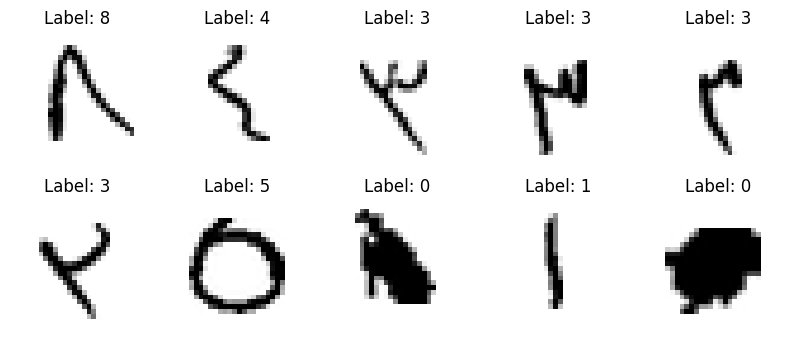

In [6]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.show()

CNN Model

In [7]:
model = Sequential([
    Input(shape=(28, 28, 1)),

    Conv2D(32, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    BatchNormalization(),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.4),

    Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,442 (947.04 KB)

 Trainable params: 241,994 (945.29 KB)

 Non-trainable params: 448 (1.75 KB)

Train Model

In [8]:
checkpoint = ModelCheckpoint(
    "best_arabic_digit_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train_cat,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[checkpoint, early_stop],
    verbose=1
)

Epoch 1/30
738/750 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9468 - loss: 0.1855
Epoch 1: val_accuracy improved from None to 0.98275, saving model to best_arabic_digit_model.keras

Epoch 1: finished saving model to best_arabic_digit_model.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9757 - loss: 0.0868 - val_accuracy: 0.9827 - val_loss: 0.0616
Epoch 2/30
740/750 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9885 - loss: 0.0382
Epoch 2: val_accuracy improved from 0.98275 to 0.99058, saving model to best_arabic_digit_model.keras

Epoch 2: finished saving model to best_arabic_digit_model.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9892 - loss: 0.0351 - val_accuracy: 0.9906 - val_loss: 0.0366
Epoch 3/30
739/750 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9924 - loss: 0.0259
Epoch 3: val_accuracy improved from 0.99058 to 0.99167, saving model to best_arabic_digit_model.keras

Epoch 3: finished saving model to best_arabic_digit_model.keras
750/750 ━

Accuracy & Loss Curves

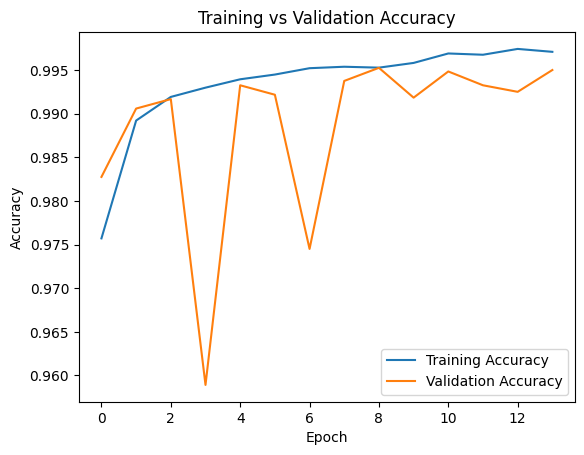

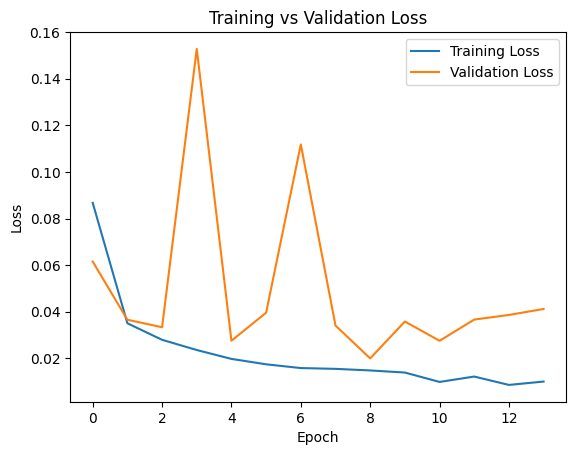

In [9]:
plt.figure()
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.savefig("accuracy_curve.png", dpi=300)
plt.show()

plt.figure()
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.savefig("loss_curve.png", dpi=300)
plt.show()

Test Evaluation

In [10]:
best_model = load_model("best_arabic_digit_model.keras")

test_loss, test_accuracy = best_model.evaluate(X_test, y_test_cat)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9901 - loss: 0.0399
Test Loss: 0.03988735005259514
Test Accuracy: 0.9901000261306763


Classification Report

In [11]:
y_pred_prob = best_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1000
           1       0.99      0.98      0.99      1000
           2       0.99      0.99      0.99      1000
           3       1.00      0.99      1.00      1000
           4       0.99      0.99      0.99      1000
           5       0.98      0.98      0.98      1000
           6       1.00      0.99      0.99      1000
           7       1.00      1.00      1.00      1000
           8       1.00      0.99      1.00      1000
           9       0.99      1.00      0.99      1000

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



Confusion Matrix

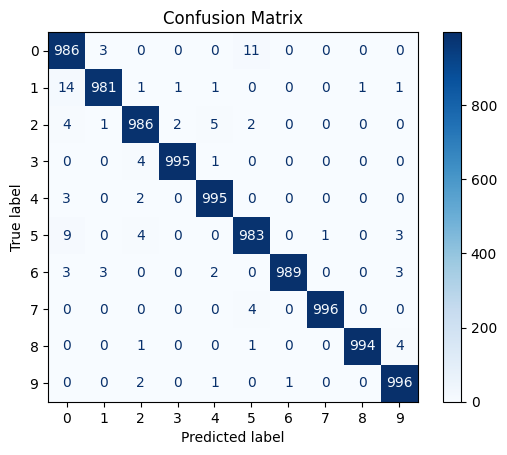

In [12]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

Predict Uploaded Image

In [13]:
def prepare_digit_like_dataset(digit_img):
    h, w = digit_img.shape

    if h > w:
        new_h = 22
        new_w = int(w * (22 / h))
    else:
        new_w = 22
        new_h = int(h * (22 / w))

    digit_resized = cv2.resize(digit_img, (new_w, new_h))

    canvas = np.ones((28, 28), dtype=np.uint8) * 255

    x_start = (28 - new_w) // 2
    y_start = (28 - new_h) // 2

    canvas[y_start:y_start + new_h, x_start:x_start + new_w] = digit_resized

    return canvas


def predict_uploaded_image_multi():
    uploaded = files.upload()
    image_name = list(uploaded.keys())[0]

    img = cv2.imread(image_name, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print("Image not found.")
        return

    blur = cv2.GaussianBlur(img, (5, 5), 0)

    _, thresh = cv2.threshold(
        blur,
        120,
        255,
        cv2.THRESH_BINARY
    )

    _, thresh_inv = cv2.threshold(
        blur,
        120,
        255,
        cv2.THRESH_BINARY_INV
    )

    contours, _ = cv2.findContours(
        thresh_inv,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    digit_boxes = []

    for c in contours:
        x, y, w, h = cv2.boundingRect(c)
        area = cv2.contourArea(c)

        if area > 20:
            digit_boxes.append((x, y, w, h))

    digit_boxes = sorted(digit_boxes, key=lambda box: box[0])

    predictions = []

    for i, (x, y, w, h) in enumerate(digit_boxes):
        margin = 5

        x1 = max(x - margin, 0)
        y1 = max(y - margin, 0)
        x2 = min(x + w + margin, thresh.shape[1])
        y2 = min(y + h + margin, thresh.shape[0])

        digit = thresh[y1:y2, x1:x2]

        kernel = np.ones((2, 2), np.uint8)
        digit = cv2.erode(digit, kernel, iterations=1)

        canvas = prepare_digit_like_dataset(digit)

        plt.imshow(canvas, cmap="gray")
        plt.title(f"Digit {i+1} - Processed")
        plt.axis("off")
        plt.show()

        input_img = canvas / 255.0
        input_img = input_img.reshape(1, 28, 28, 1)

        pred = best_model.predict(input_img)
        predicted_digit = np.argmax(pred)
        confidence = np.max(pred) * 100

        print(f"Digit {i+1}: {predicted_digit}")
        print("Confidence:", round(confidence, 2), "%")

        predictions.append(int(predicted_digit))

    print("Final prediction:", predictions)

    return predictions

Run Prediction

Saving arabic_test_imageat 1.56.08 PM.jpeg to arabic_test_imageat 1.56.08 PM.jpeg


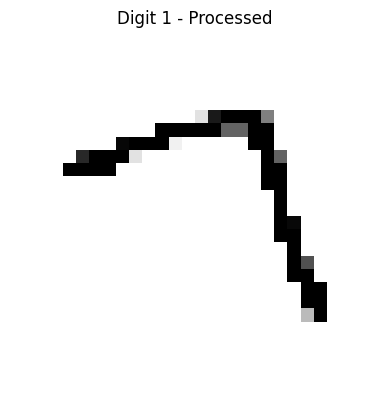

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 524ms/step
Digit 1: 6
Confidence: 100.0 %


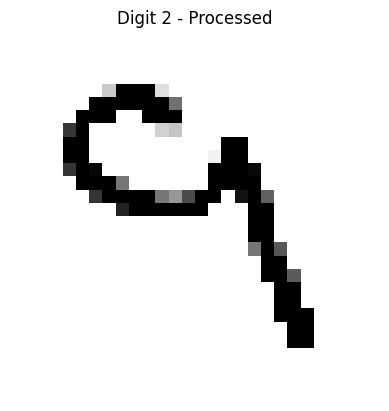

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Digit 2: 9
Confidence: 100.0 %


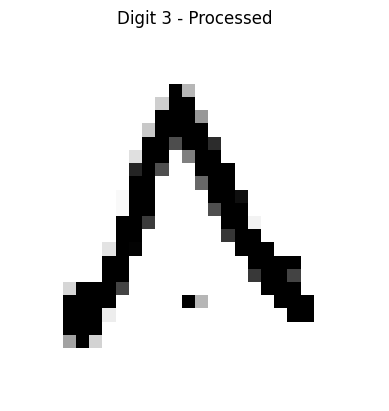

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Digit 3: 8
Confidence: 100.0 %


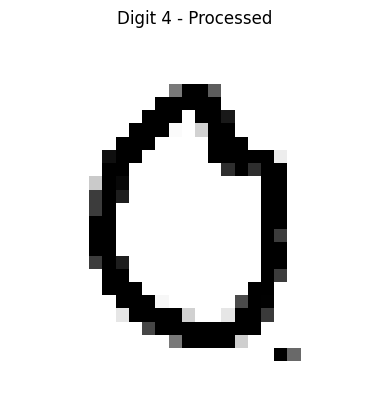

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Digit 4: 5
Confidence: 100.0 %


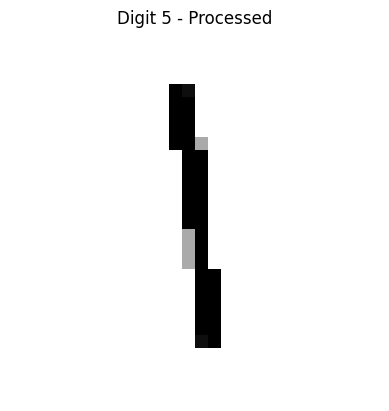

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Digit 5: 1
Confidence: 100.0 %


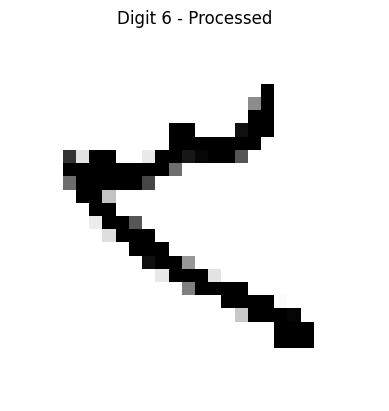

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Digit 6: 3
Confidence: 100.0 %


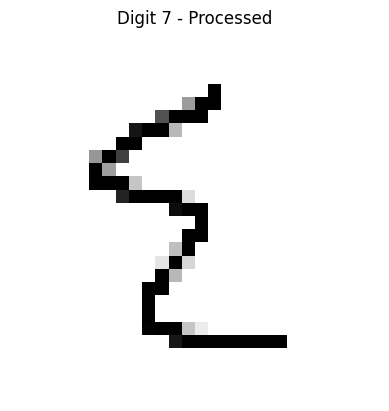

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Digit 7: 4
Confidence: 100.0 %
Final prediction: [6, 9, 8, 5, 1, 3, 4]


[6, 9, 8, 5, 1, 3, 4]

In [14]:
predict_uploaded_image_multi()

Results

In [ ]:
# Test Accuracy: XX.XX %

# The model was evaluated on the MAHDBase testing dataset.

# Generated outputs:
# - Accuracy Curve
# - Loss Curve
# - Confusion Matrix
# - Classification Report